<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-team-dataset-97?scriptVersionId=317537997" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/harrachimustapha/fifa-world-cup-team-dataset/train.csv
/kaggle/input/datasets/harrachimustapha/fifa-world-cup-team-dataset/test.csv


## Loading dataset

In [2]:
train_path = "/kaggle/input/datasets/harrachimustapha/fifa-world-cup-team-dataset/train.csv"
test_path = "/kaggle/input/datasets/harrachimustapha/fifa-world-cup-team-dataset/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [3]:
print("\n================ TRAIN DATA =================")
print(train_df.head())

print("\n================ TEST DATA =================")
print(test_df.head())


================ TRAIN DATA =================
   version        team      continent  is_host  goals_scored_last_4y  \
0     2006      Angola         Africa        0                    61   
1     2006   Argentina  South America        0                    97   
2     2006   Australia        Oceania        0                   101   
3     2006      Brazil  South America        0                   117   
4     2006  Costa Rica  North America        0                    89   

   goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
0                      49            19              13             14   
1                      55            31              10             10   
2                      34            23               8              5   
3                      47            30               9             17   
4                      84            26              25             11   

   world_cup_titles_before  ...  world_cup_participations_before  \
0      

In [4]:
print("\n================ DATASET SHAPE ================")

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)



================ DATASET SHAPE ================
Train Shape : (192, 24)
Test Shape  : (48, 24)


In [5]:
print("\n================ COLUMN NAMES ================")

print("Train Columns:\n")
print(train_df.columns)

print("\nTest Columns:\n")
print(test_df.columns)


================ COLUMN NAMES ================
Train Columns:

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

Test Columns:

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'gr

In [6]:
print("\n================ DATA TYPES ================")

print(train_df.dtypes)


================ DATA TYPES ================
version                              int64
team                                object
continent                           object
is_host                              int64
goals_scored_last_4y                 int64
goals_received_last_4y               int64
wins_last_4y                         int64
losses_last_4y                       int64
draws_last_4y                        int64
world_cup_titles_before              int64
squad_total_market_value_eur       float64
fifa_rank_pre_tournament             int64
fifa_points_pre_tournament         float64
squad_avg_age                      float64
world_cup_participations_before      int64
groups_passed_before                 int64
round16_before                       int64
quarterfinals_before                 int64
semifinals_before                    int64
finals_before                        int64
winner                               int64
finalist                             int64
semi_fin

In [7]:
print("\n================ TRAIN INFO ================")

print(train_df.info())

print("\n================ TEST INFO ================")

print(test_df.info())


================ TRAIN INFO ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    object 
 2   continent                        192 non-null    object 
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 n

In [8]:
print("\n================ MISSING VALUES ================")

print("Train Missing Values:\n")
print(train_df.isnull().sum())

print("\nTest Missing Values:\n")
print(test_df.isnull().sum())



================ MISSING VALUES ================
Train Missing Values:

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur       32
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                              0
finalist                            0
semi_finalist                       0
quarter_finalist                    0
dtype: int64

T

In [9]:
print("\n================ DUPLICATE ROWS ================")

print("Train Duplicate Rows :", train_df.duplicated().sum())
print("Test Duplicate Rows  :", test_df.duplicated().sum())



================ DUPLICATE ROWS ================
Train Duplicate Rows : 0
Test Duplicate Rows  : 0


In [10]:
print("\n================ NUMERICAL SUMMARY ================")

print(train_df.describe())


================ NUMERICAL SUMMARY ================
          version     is_host  goals_scored_last_4y  goals_received_last_4y  \
count   192.00000  192.000000            192.000000              192.000000   
mean   2012.00000    0.036458             84.583333               44.572917   
std       6.84916    0.187918             23.731776               13.608009   
min    2002.00000    0.000000             28.000000               19.000000   
25%    2006.00000    0.000000             66.000000               35.000000   
50%    2012.00000    0.000000             83.500000               42.500000   
75%    2018.00000    0.000000            102.000000               53.250000   
max    2022.00000    1.000000            156.000000               95.000000   

       wins_last_4y  losses_last_4y  draws_last_4y  world_cup_titles_before  \
count    192.000000      192.000000     192.000000               192.000000   
mean      26.046875       11.052083      11.802083                 0.427083  

In [11]:
print("\n================ CATEGORICAL SUMMARY ================")

print(train_df.describe(include='object'))



================ CATEGORICAL SUMMARY ================
             team continent
count         192       192
unique         62         6
top     Argentina    Europe
freq            6        82


In [12]:
print("\n================ UNIQUE VALUES ================")

for col in train_df.columns:
    print(f"{col} : {train_df[col].nunique()}")


================ UNIQUE VALUES ================
version : 6
team : 62
continent : 6
is_host : 2
goals_scored_last_4y : 83
goals_received_last_4y : 54
wins_last_4y : 33
losses_last_4y : 23
draws_last_4y : 19
world_cup_titles_before : 6
squad_total_market_value_eur : 158
fifa_rank_pre_tournament : 60
fifa_points_pre_tournament : 182
squad_avg_age : 110
world_cup_participations_before : 22
groups_passed_before : 19
round16_before : 12
quarterfinals_before : 17
semifinals_before : 13
finals_before : 9
winner : 2
finalist : 2
semi_finalist : 2
quarter_finalist : 2


In [13]:
print("\n================ VALUE COUNTS ================")

# Example for first categorical column
for col in train_df.select_dtypes(include='object').columns[:5]:
    print(f"\nColumn : {col}")
    print(train_df[col].value_counts())


================ VALUE COUNTS ================

Column : team
team
Argentina                 6
Brazil                    6
England                   6
Germany                   6
France                    6
                         ..
North Korea               1
Bosnia and Herzegovina    1
China PR                  1
Republic of Ireland       1
Turkey                    1
Name: count, Length: 62, dtype: int64

Column : continent
continent
Europe           82
Africa           31
South America    29
Asia             23
North America    21
Oceania           6
Name: count, dtype: int64


In [14]:
print("\n================ NUMERICAL COLUMNS ================")

num_cols = train_df.select_dtypes(include=np.number).columns

print(num_cols)


================ NUMERICAL COLUMNS ================
Index(['version', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
       'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
       'world_cup_titles_before', 'squad_total_market_value_eur',
       'fifa_rank_pre_tournament', 'fifa_points_pre_tournament',
       'squad_avg_age', 'world_cup_participations_before',
       'groups_passed_before', 'round16_before', 'quarterfinals_before',
       'semifinals_before', 'finals_before', 'winner', 'finalist',
       'semi_finalist', 'quarter_finalist'],
      dtype='object')


In [15]:
print("\n================ CATEGORICAL COLUMNS ================")

cat_cols = train_df.select_dtypes(include='object').columns

print(cat_cols)


================ CATEGORICAL COLUMNS ================
Index(['team', 'continent'], dtype='object')


In [16]:
print("\n================ HANDLE MISSING VALUES ================")

# Numerical columns -> Fill with median
for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(test_df[col].median())

# Categorical columns -> Fill with mode
for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

    # Only fill if column exists in test
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

print("Missing Values Handled Successfully")


================ HANDLE MISSING VALUES ================
Missing Values Handled Successfully


In [17]:

print("\n================ REMOVE DUPLICATES ================")

train_df = train_df.drop_duplicates()

print("New Train Shape :", train_df.shape)


================ REMOVE DUPLICATES ================
New Train Shape : (192, 24)


In [18]:
print("\n================ SORT DATA ================")

# Example sorting using first numerical column
if len(num_cols) > 0:
    sort_col = num_cols[0]

    sorted_df = train_df.sort_values(by=sort_col, ascending=False)

    print(sorted_df.head())


================ SORT DATA ================
    version           team      continent  is_host  goals_scored_last_4y  \
95     2022          Wales         Europe        0                    54   
94     2022        Uruguay  South America        0                    63   
93     2022  United States  North America        0                   119   
92     2022        Tunisia         Africa        0                    84   
91     2022    Switzerland         Europe        0                    90   

    goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
95                      51            21              16             12   
94                      42            20              12             12   
93                      47            37              14             11   
92                      39            33              14             10   
91                      57            22              15             13   

    world_cup_titles_before  ...  world_cup_par

In [19]:
print("\n================ FILTER DATA ================")

# Example filtering
if len(num_cols) > 0:
    filter_col = num_cols[0]

    filtered_df = train_df[train_df[filter_col] > train_df[filter_col].mean()]

    print(filtered_df.head())




================ FILTER DATA ================
    version       team      continent  is_host  goals_scored_last_4y  \
32     2018  Argentina  South America        0                    95   
33     2018  Australia        Oceania        0                    85   
34     2018    Belgium         Europe        0                   116   
35     2018     Brazil  South America        0                    95   
36     2018   Colombia  South America        0                    57   

    goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
32                      40            27               8             12   
33                      48            23              11             12   
34                      38            30               5              8   
35                      22            33               4              8   
36                      37            19              11             13   

    world_cup_titles_before  ...  world_cup_participations_before  \


In [20]:
print("\n================ GROUPBY OPERATIONS ================")

if len(cat_cols) > 0 and len(num_cols) > 0:

    group_col = cat_cols[0]
    agg_col = num_cols[0]

    grouped_data = train_df.groupby(group_col)[agg_col].mean()

    print(grouped_data.head())


================ GROUPBY OPERATIONS ================
team
Algeria      2012.0
Angola       2006.0
Argentina    2012.0
Australia    2014.0
Belgium      2014.0
Name: version, dtype: float64


In [21]:
print("\n================ FEATURE ENGINEERING ================")

if len(num_cols) >= 2:

    train_df['New_Feature'] = train_df[num_cols[0]] + train_df[num_cols[1]]

    print(train_df[['New_Feature']].head())




================ FEATURE ENGINEERING ================
   New_Feature
0         2006
1         2006
2         2006
3         2006
4         2006


In [22]:
print("\n================ RENAME COLUMN ================")

if len(train_df.columns) > 0:

    old_name = train_df.columns[0]
    train_df.rename(columns={old_name: old_name + "_renamed"}, inplace=True)

    print(train_df.columns[:5])


================ RENAME COLUMN ================
Index(['version_renamed', 'team', 'continent', 'is_host',
       'goals_scored_last_4y'],
      dtype='object')


In [23]:
print("\n================ CORRELATION MATRIX ================")

correlation = train_df.select_dtypes(include=np.number).corr()

print(correlation)



================ CORRELATION MATRIX ================
                                 version_renamed   is_host  \
version_renamed                     1.000000e+00 -0.040678   
is_host                            -4.067820e-02  1.000000   
goals_scored_last_4y                8.194381e-02  0.092648   
goals_received_last_4y             -1.118984e-01  0.161724   
wins_last_4y                        1.134591e-01  0.067196   
losses_last_4y                     -1.088889e-01  0.150504   
draws_last_4y                      -1.495571e-01  0.146519   
world_cup_titles_before            -1.408656e-02  0.000267   
squad_total_market_value_eur        5.285443e-02 -0.030618   
fifa_rank_pre_tournament           -4.868219e-03  0.202228   
fifa_points_pre_tournament          7.201928e-01 -0.092197   
squad_avg_age                       2.671795e-02  0.009757   
world_cup_participations_before     1.427185e-01 -0.067156   
groups_passed_before                8.336320e-02 -0.060831   
round16_before  

In [24]:
print("\n================ MEMORY USAGE ================")

print(train_df.memory_usage(deep=True))



================ MEMORY USAGE ================
Index                                132
version_renamed                     1536
team                               10905
continent                          10870
is_host                             1536
goals_scored_last_4y                1536
goals_received_last_4y              1536
wins_last_4y                        1536
losses_last_4y                      1536
draws_last_4y                       1536
world_cup_titles_before             1536
squad_total_market_value_eur        1536
fifa_rank_pre_tournament            1536
fifa_points_pre_tournament          1536
squad_avg_age                       1536
world_cup_participations_before     1536
groups_passed_before                1536
round16_before                      1536
quarterfinals_before                1536
semifinals_before                   1536
finals_before                       1536
winner                              1536
finalist                            1536
semi_fina

In [25]:
print("\n================ EXPORT DATA ================")

train_df.to_csv("cleaned_train.csv", index=False)
test_df.to_csv("cleaned_test.csv", index=False)

print("Cleaned CSV Files Saved Successfully")


================ EXPORT DATA ================
Cleaned CSV Files Saved Successfully


In [26]:
print("\n================ FINAL DATASET ================")

print(train_df.head())

print("\nFinal Train Shape :", train_df.shape)
print("Final Test Shape  :", test_df.shape)

print("\nPANDAS DATA ANALYSIS COMPLETED SUCCESSFULLY")


================ FINAL DATASET ================
   version_renamed        team      continent  is_host  goals_scored_last_4y  \
0             2006      Angola         Africa        0                    61   
1             2006   Argentina  South America        0                    97   
2             2006   Australia        Oceania        0                   101   
3             2006      Brazil  South America        0                   117   
4             2006  Costa Rica  North America        0                    89   

   goals_received_last_4y  wins_last_4y  losses_last_4y  draws_last_4y  \
0                      49            19              13             14   
1                      55            31              10             10   
2                      34            23               8              5   
3                      47            30               9             17   
4                      84            26              25             11   

   world_cup_titles_befor

## EDA

In [27]:
train_path = "/kaggle/input/datasets/harrachimustapha/fifa-world-cup-team-dataset/train.csv"

df = pd.read_csv(train_path)


In [28]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

print("\nNumerical Columns:\n")
print(num_cols)

print("\nCategorical Columns:\n")
print(cat_cols)


Numerical Columns:

Index(['version', 'is_host', 'goals_scored_last_4y', 'goals_received_last_4y',
       'wins_last_4y', 'losses_last_4y', 'draws_last_4y',
       'world_cup_titles_before', 'squad_total_market_value_eur',
       'fifa_rank_pre_tournament', 'fifa_points_pre_tournament',
       'squad_avg_age', 'world_cup_participations_before',
       'groups_passed_before', 'round16_before', 'quarterfinals_before',
       'semifinals_before', 'finals_before', 'winner', 'finalist',
       'semi_finalist', 'quarter_finalist'],
      dtype='object')

Categorical Columns:

Index(['team', 'continent'], dtype='object')


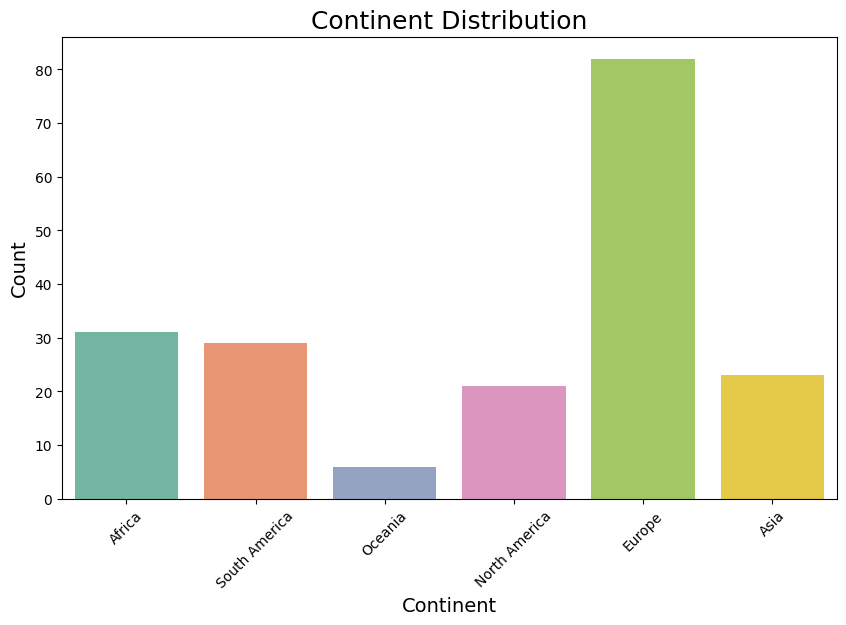

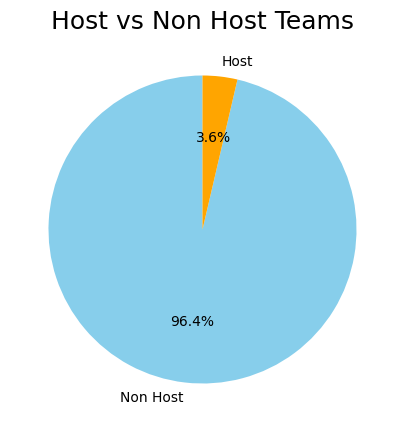

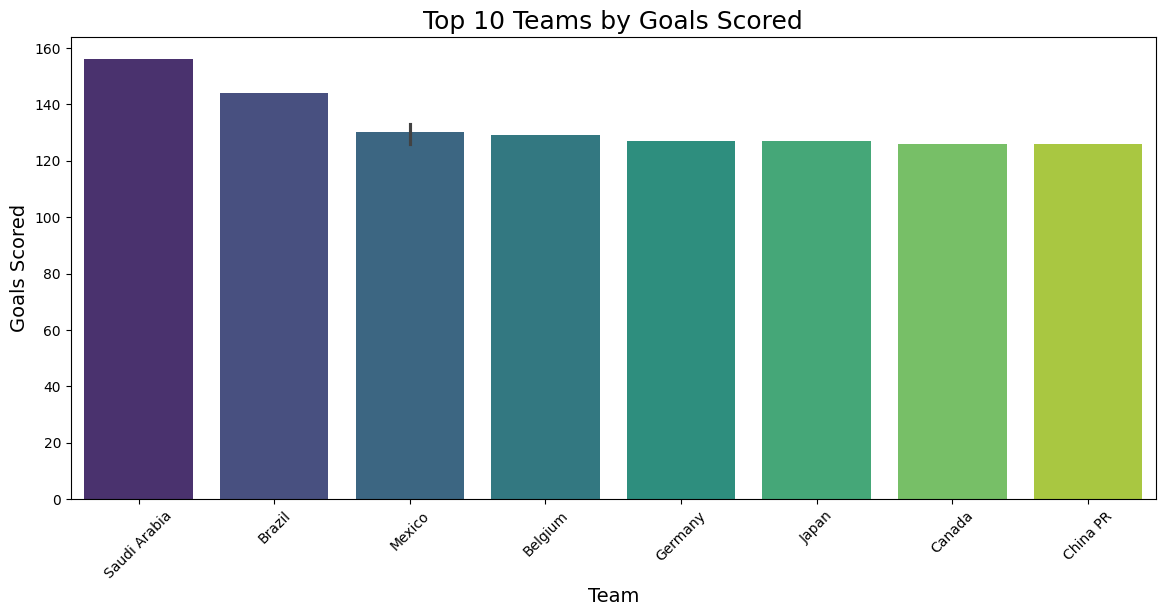

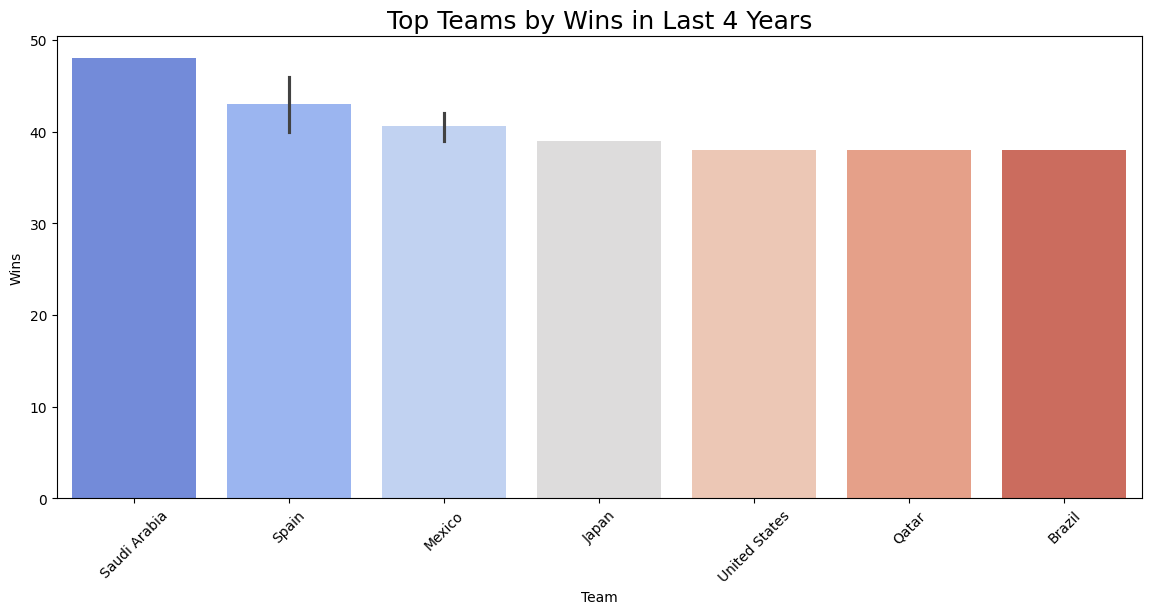

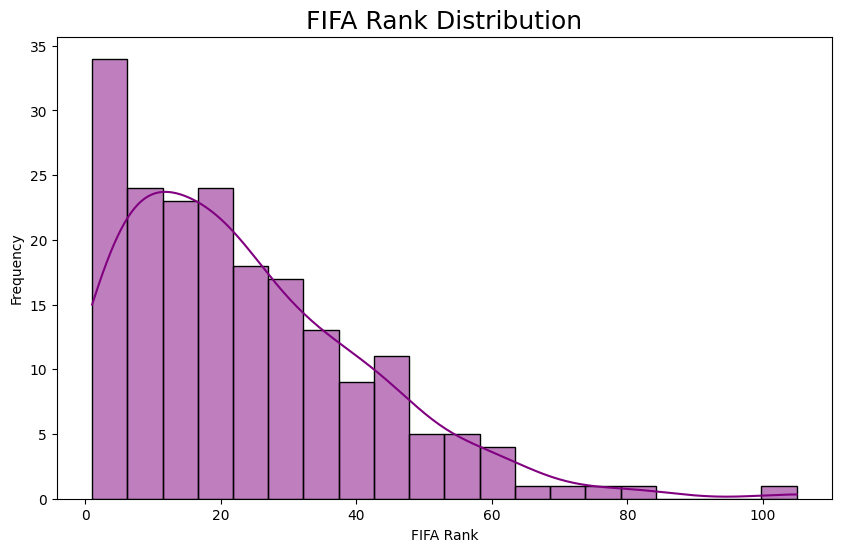

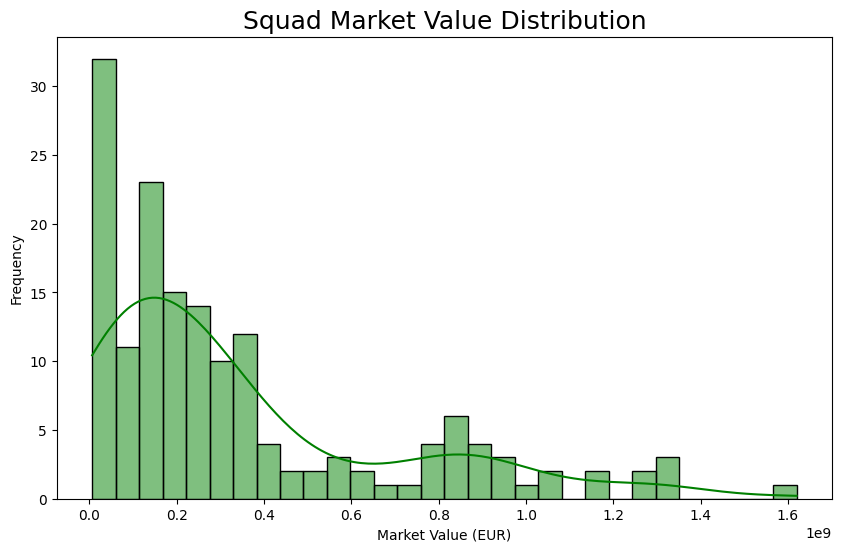

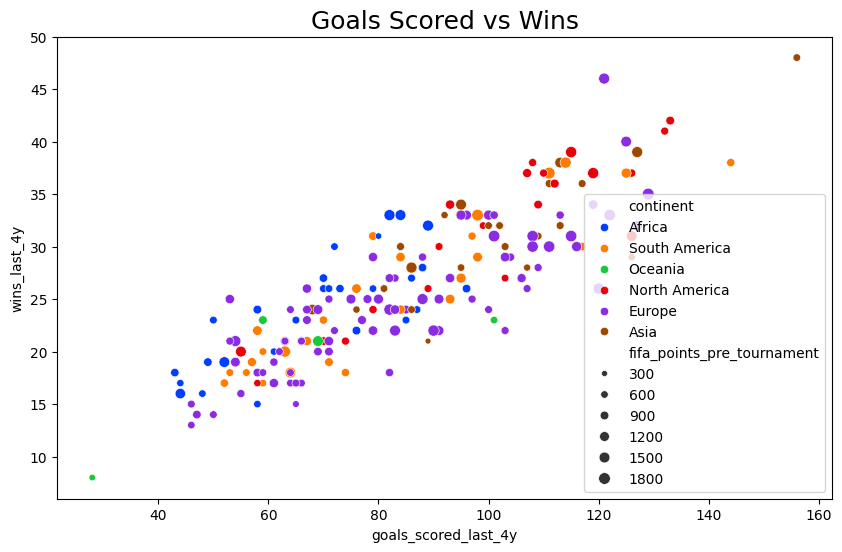

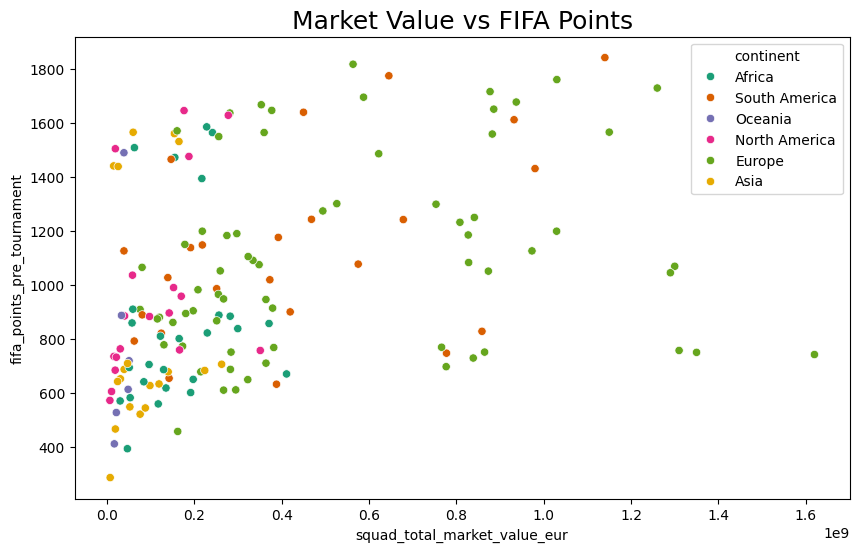

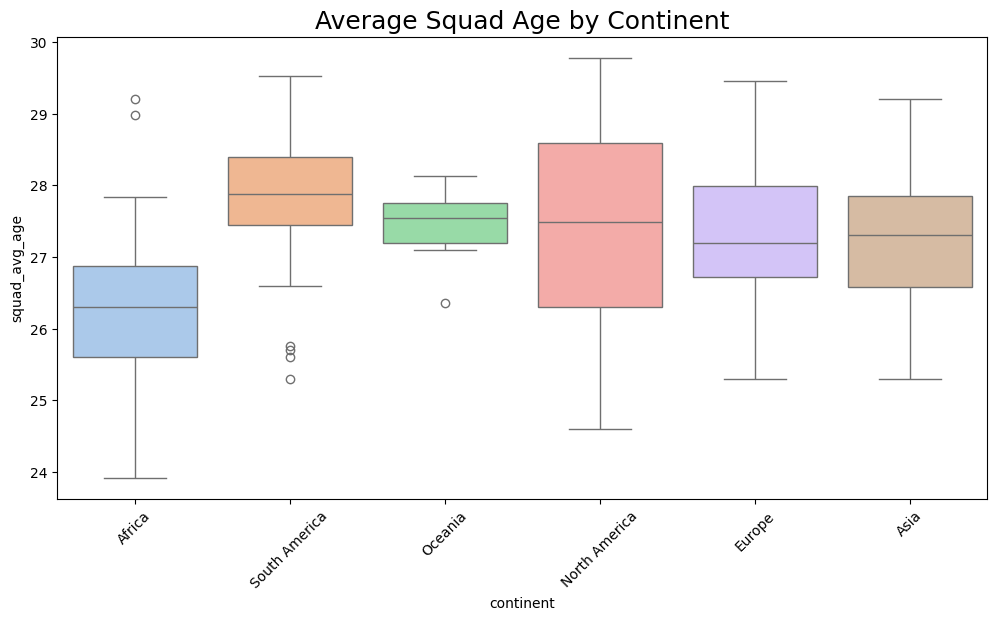

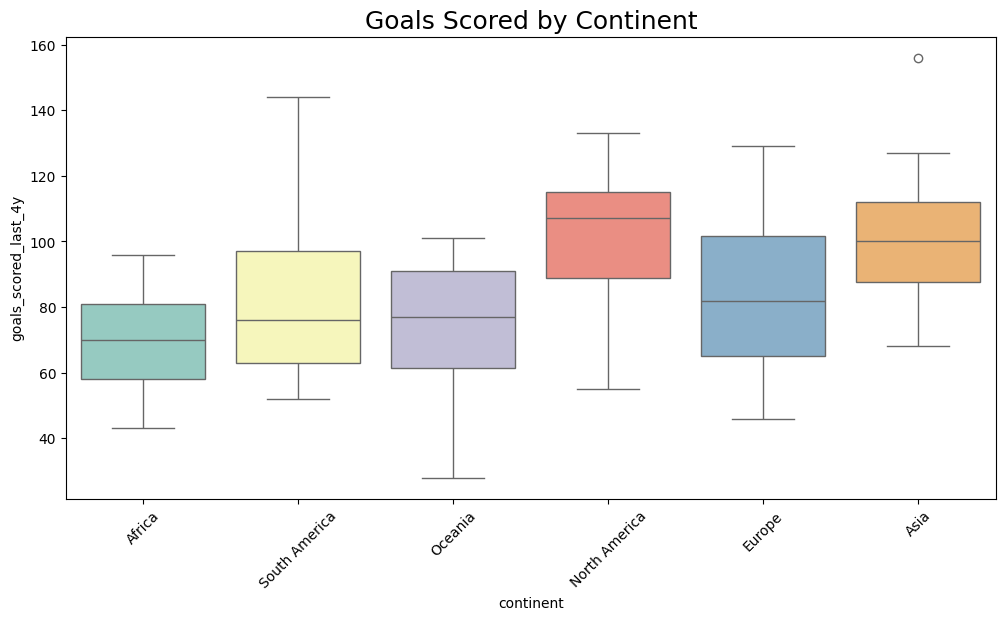

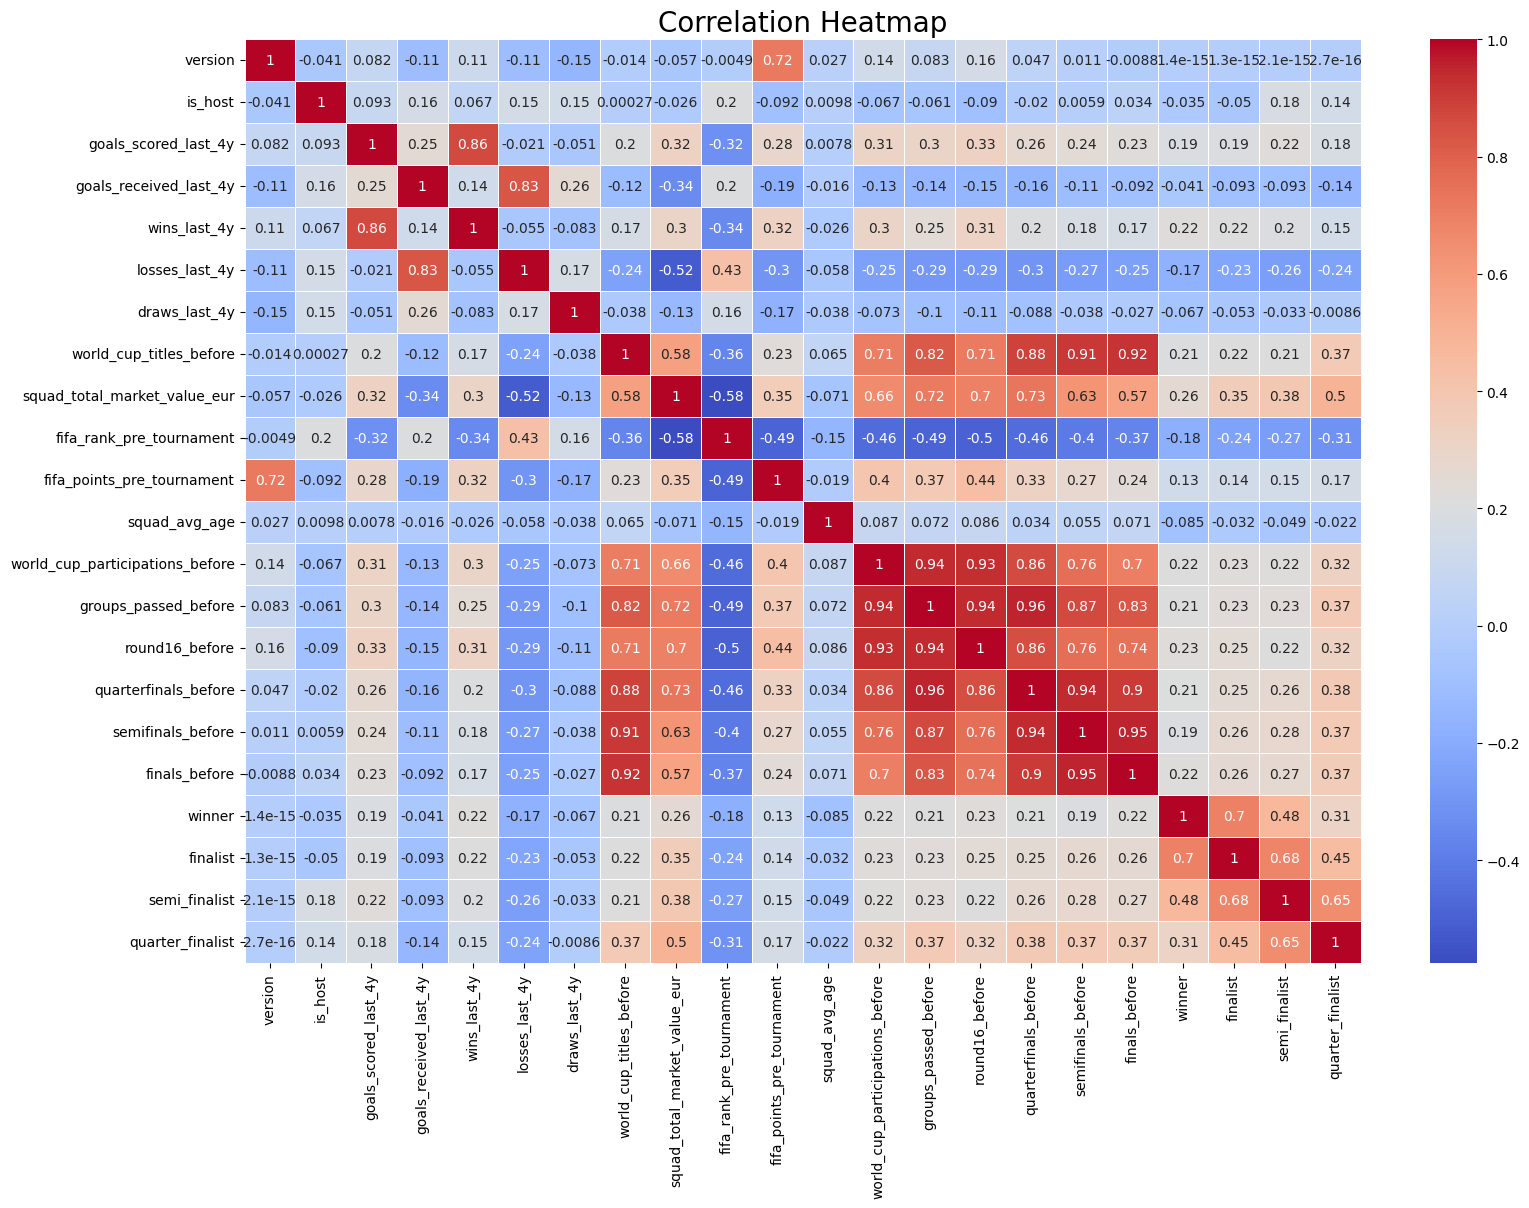

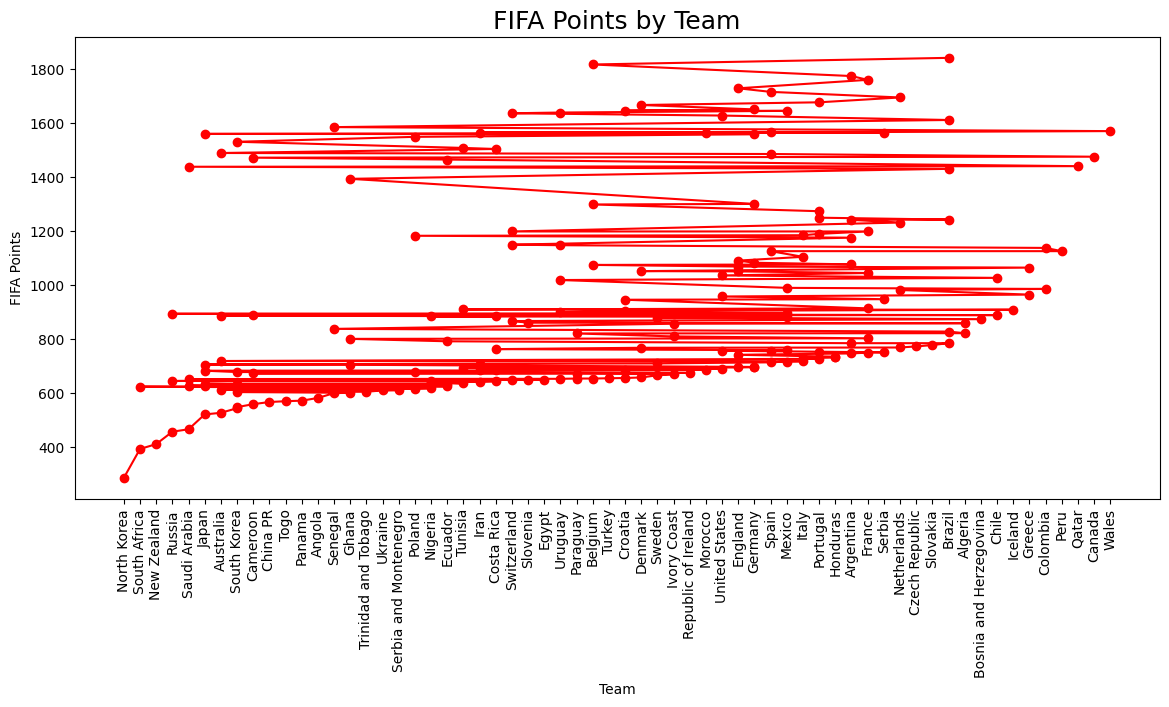

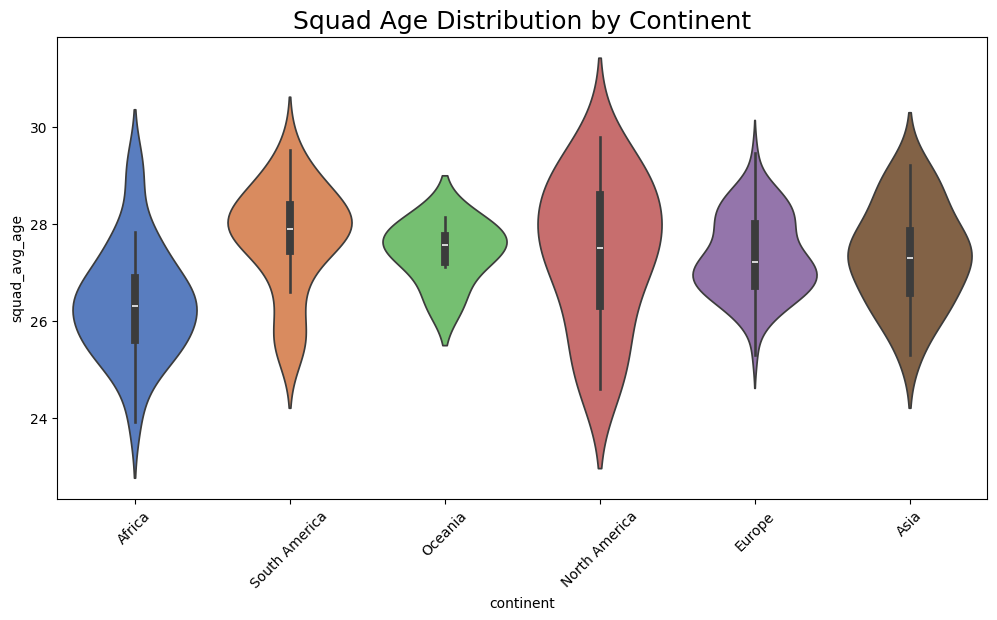

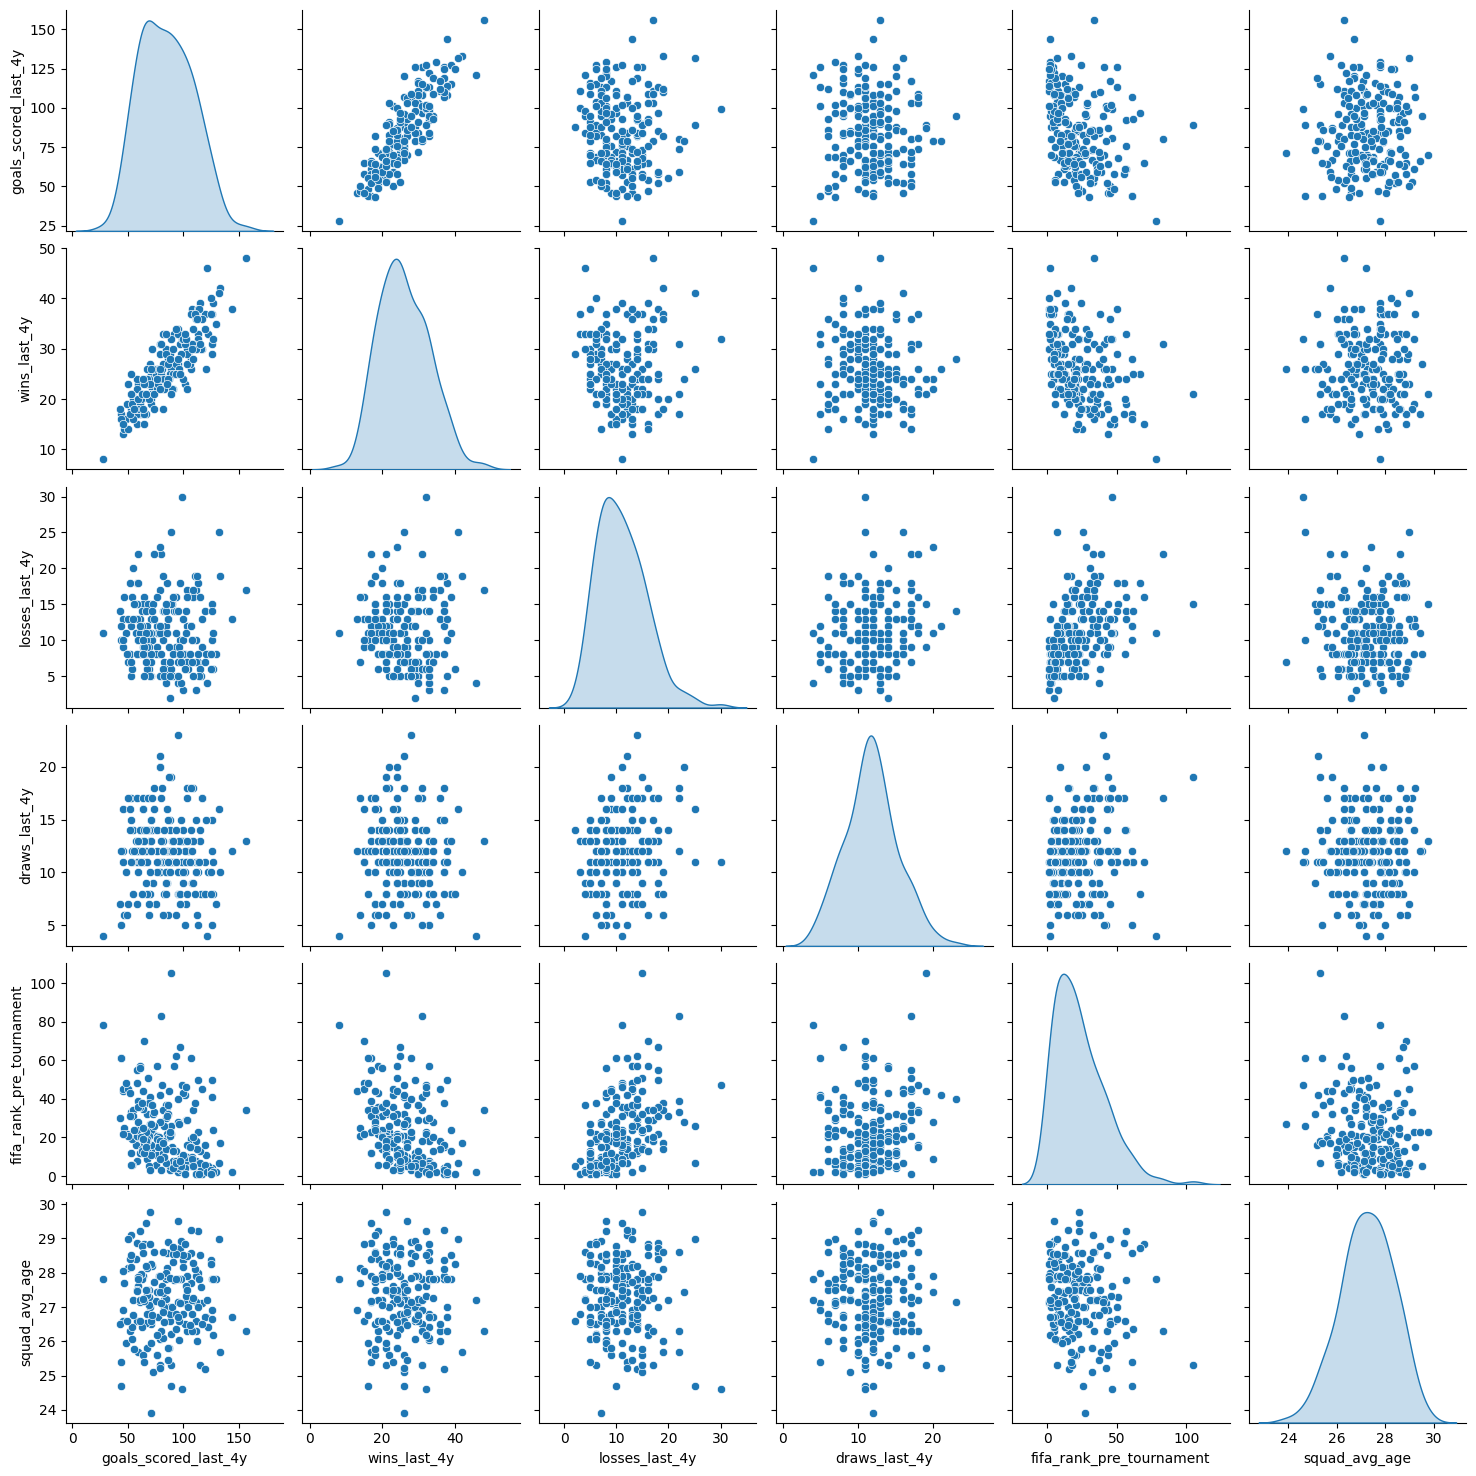

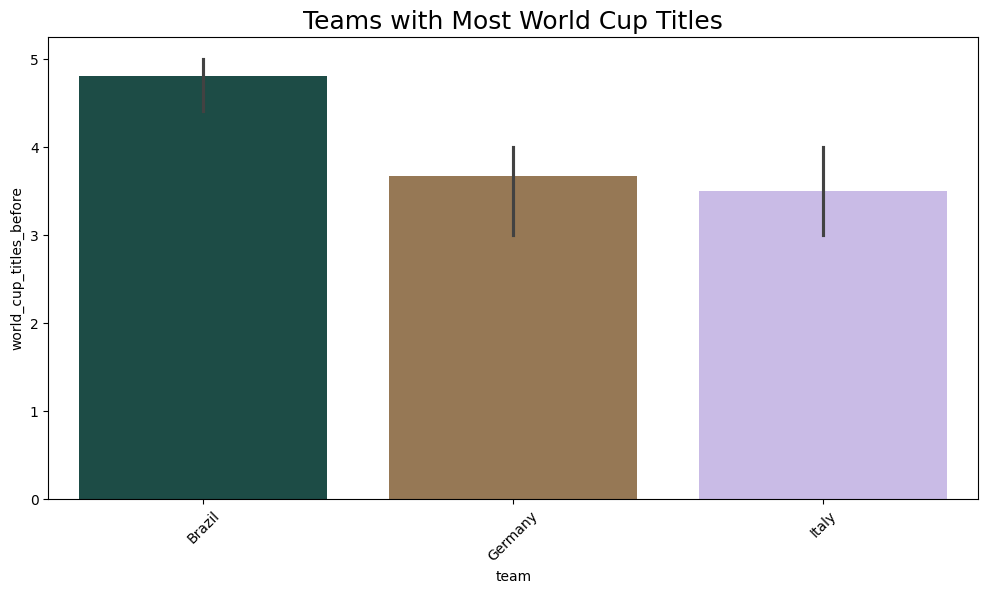

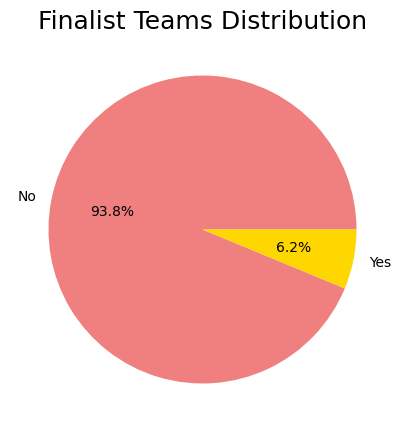

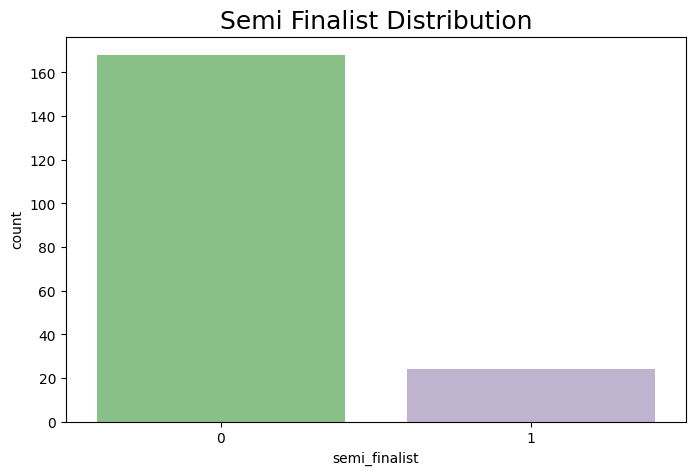

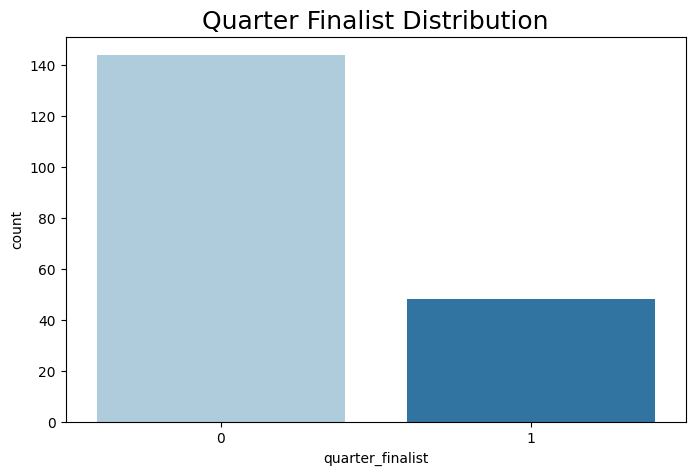

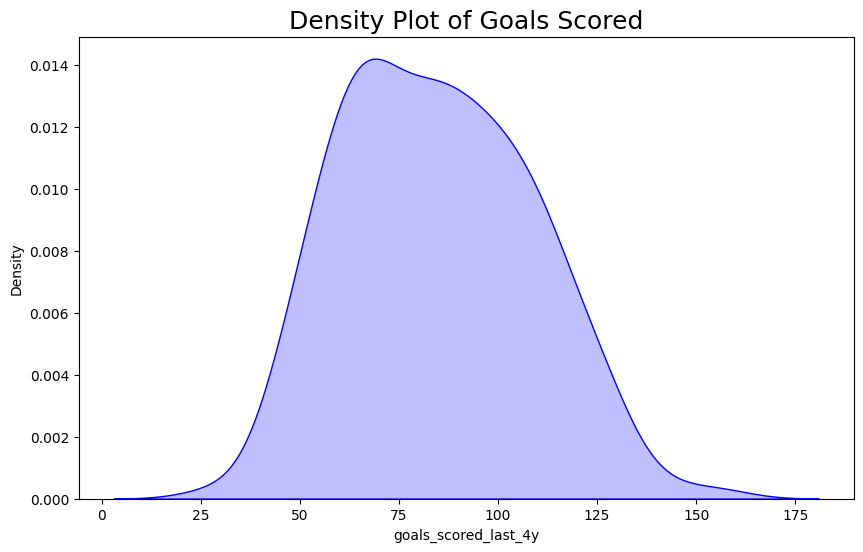


Visualization Completed Successfully
Cleaned Dataset Saved


In [29]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='continent',
    data=df,
    palette='Set2'
)

plt.title("Continent Distribution", fontsize=18)
plt.xlabel("Continent", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 7 : HOST COUNTRY DISTRIBUTION
# ============================================================

plt.figure(figsize=(6,5))

host_counts = df['is_host'].value_counts()

plt.pie(
    host_counts,
    labels=['Non Host', 'Host'],
    autopct='%1.1f%%',
    colors=['skyblue', 'orange'],
    startangle=90
)

plt.title("Host vs Non Host Teams", fontsize=18)

plt.show()

# ============================================================
# STEP 8 : TOP TEAMS BY GOALS SCORED
# ============================================================

top_goal_teams = df.sort_values(
    by='goals_scored_last_4y',
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x='team',
    y='goals_scored_last_4y',
    data=top_goal_teams,
    palette='viridis'
)

plt.title("Top 10 Teams by Goals Scored", fontsize=18)
plt.xlabel("Team", fontsize=14)
plt.ylabel("Goals Scored", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 9 : TOP TEAMS BY WINS
# ============================================================

top_wins = df.sort_values(
    by='wins_last_4y',
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x='team',
    y='wins_last_4y',
    data=top_wins,
    palette='coolwarm'
)

plt.title("Top Teams by Wins in Last 4 Years", fontsize=18)
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 10 : FIFA RANK DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['fifa_rank_pre_tournament'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("FIFA Rank Distribution", fontsize=18)
plt.xlabel("FIFA Rank")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# STEP 11 : MARKET VALUE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['squad_total_market_value_eur'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Squad Market Value Distribution", fontsize=18)
plt.xlabel("Market Value (EUR)")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# STEP 12 : SCATTERPLOT - GOALS VS WINS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='goals_scored_last_4y',
    y='wins_last_4y',
    hue='continent',
    size='fifa_points_pre_tournament',
    palette='bright',
    data=df
)

plt.title("Goals Scored vs Wins", fontsize=18)

plt.show()

# ============================================================
# STEP 13 : SCATTERPLOT - MARKET VALUE VS FIFA POINTS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='squad_total_market_value_eur',
    y='fifa_points_pre_tournament',
    hue='continent',
    palette='Dark2',
    data=df
)

plt.title("Market Value vs FIFA Points", fontsize=18)

plt.show()

# ============================================================
# STEP 14 : BOXPLOT - AGE BY CONTINENT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='continent',
    y='squad_avg_age',
    data=df,
    palette='pastel'
)

plt.title("Average Squad Age by Continent", fontsize=18)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 15 : BOXPLOT - GOALS BY CONTINENT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='continent',
    y='goals_scored_last_4y',
    data=df,
    palette='Set3'
)

plt.title("Goals Scored by Continent", fontsize=18)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 16 : HEATMAP - CORRELATION MATRIX
# ============================================================

plt.figure(figsize=(18,12))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# ============================================================
# STEP 17 : LINEPLOT - FIFA POINTS
# ============================================================

sorted_df = df.sort_values(by='fifa_points_pre_tournament')

plt.figure(figsize=(14,6))

plt.plot(
    sorted_df['team'],
    sorted_df['fifa_points_pre_tournament'],
    color='red',
    marker='o'
)

plt.title("FIFA Points by Team", fontsize=18)
plt.xlabel("Team")
plt.ylabel("FIFA Points")

plt.xticks(rotation=90)

plt.show()

# ============================================================
# STEP 18 : VIOLINPLOT - AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    x='continent',
    y='squad_avg_age',
    data=df,
    palette='muted'
)

plt.title("Squad Age Distribution by Continent", fontsize=18)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 19 : PAIRPLOT
# ============================================================

selected_columns = [
    'goals_scored_last_4y',
    'wins_last_4y',
    'losses_last_4y',
    'draws_last_4y',
    'fifa_rank_pre_tournament',
    'squad_avg_age'
]

sns.pairplot(
    df[selected_columns],
    diag_kind='kde'
)

plt.show()

# ============================================================
# STEP 20 : WORLD CUP TITLES ANALYSIS
# ============================================================

top_titles = df.sort_values(
    by='world_cup_titles_before',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='team',
    y='world_cup_titles_before',
    data=top_titles,
    palette='cubehelix'
)

plt.title("Teams with Most World Cup Titles", fontsize=18)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# STEP 21 : FINALISTS ANALYSIS
# ============================================================

plt.figure(figsize=(6,5))

finalist_counts = df['finalist'].value_counts()

plt.pie(
    finalist_counts,
    labels=['No', 'Yes'],
    autopct='%1.1f%%',
    colors=['lightcoral', 'gold']
)

plt.title("Finalist Teams Distribution", fontsize=18)

plt.show()

# ============================================================
# STEP 22 : SEMI FINALIST ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='semi_finalist',
    data=df,
    palette='Accent'
)

plt.title("Semi Finalist Distribution", fontsize=18)

plt.show()

# ============================================================
# STEP 23 : QUARTER FINALIST ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='quarter_finalist',
    data=df,
    palette='Paired'
)

plt.title("Quarter Finalist Distribution", fontsize=18)

plt.show()

# ============================================================
# STEP 24 : KDE PLOT - GOALS SCORED
# ============================================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    df['goals_scored_last_4y'],
    shade=True,
    color='blue'
)

plt.title("Density Plot of Goals Scored", fontsize=18)

plt.show()

# ============================================================
# STEP 25 : SAVE CLEANED DATA
# ============================================================

df.to_csv("fifa_worldcup_cleaned.csv", index=False)

print("\nVisualization Completed Successfully")
print("Cleaned Dataset Saved")

## Feature engineering


Missing Values Handled Successfully

TARGET COLUMN
Target : winner

Target Value Counts:

winner
0    186
1      6
Name: count, dtype: int64

Feature Shape : (192, 23)
Target Shape  : (192,)

TRAIN TEST SPLIT
X_train Shape : (153, 23)
X_test Shape  : (39, 23)
y_train Shape : (153,)
y_test Shape  : (39,)

Encoding Completed Successfully


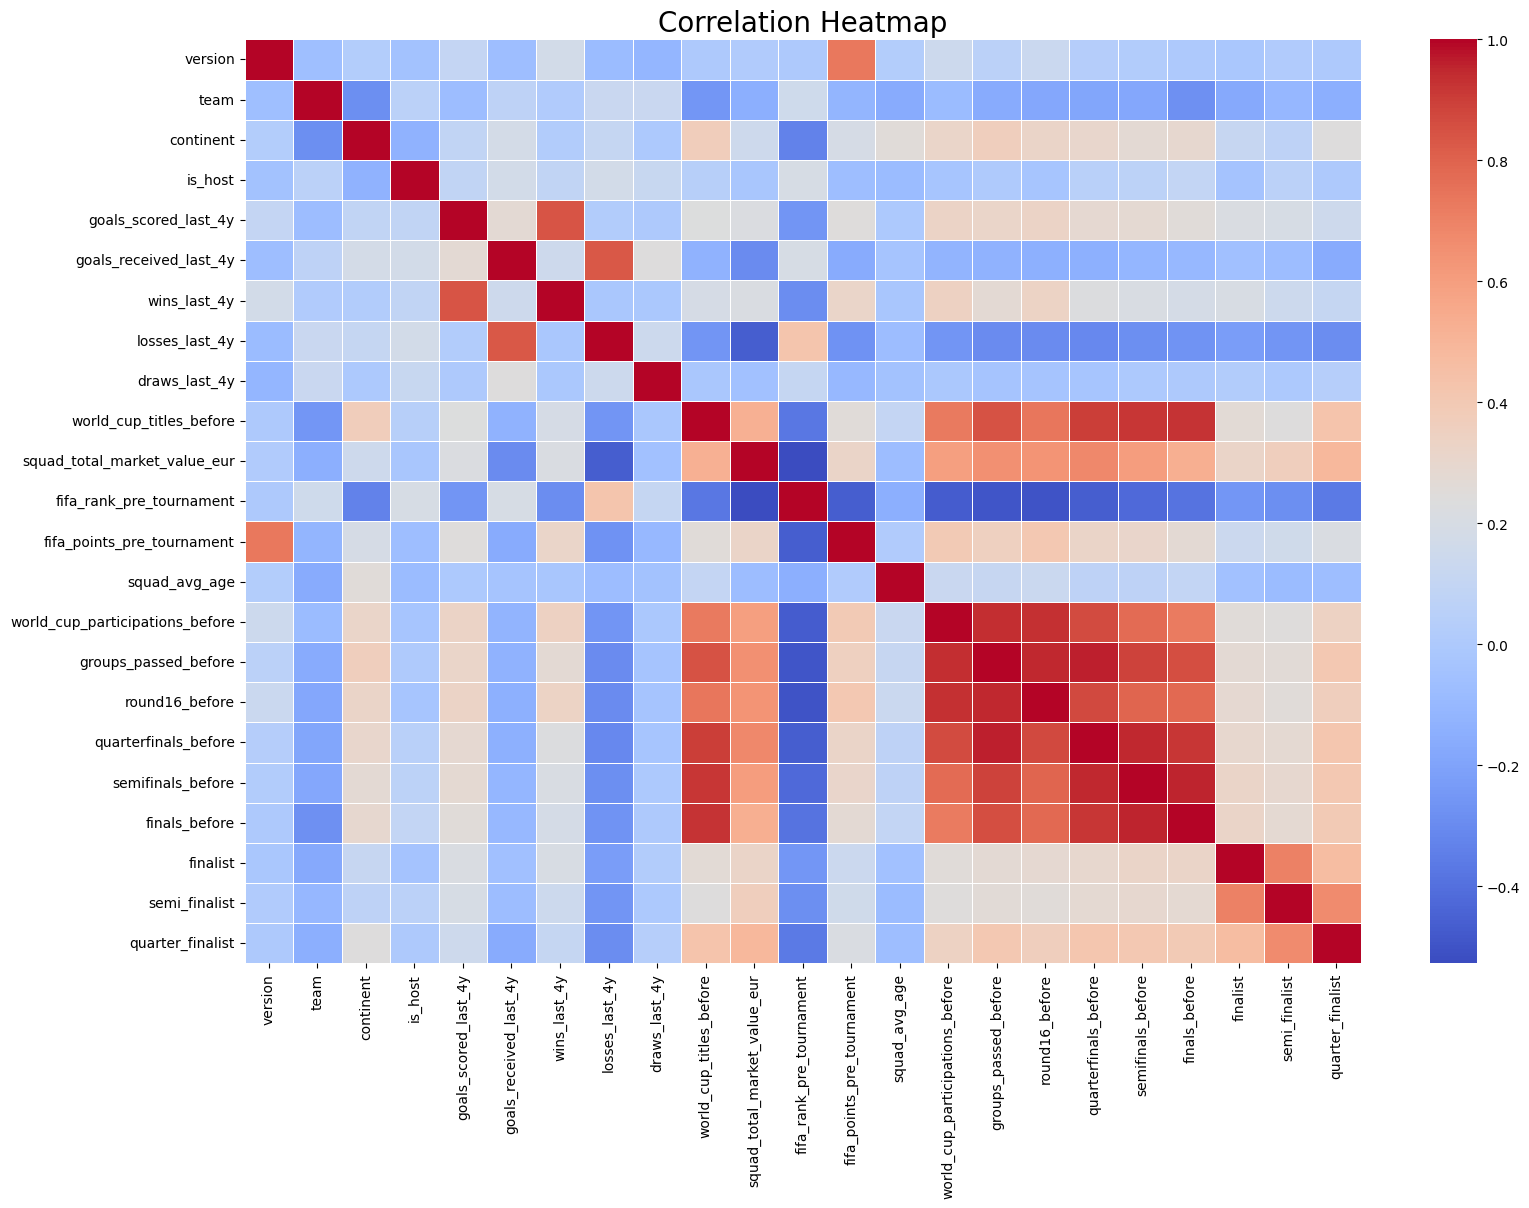


MODEL : Logistic Regression

Accuracy Score : 0.9744
Precision Score : 0.0000
Recall Score : 0.0000
F1 Score : 0.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


Confusion Matrix:

[[38  0]
 [ 1  0]]


<Figure size 1200x800 with 0 Axes>

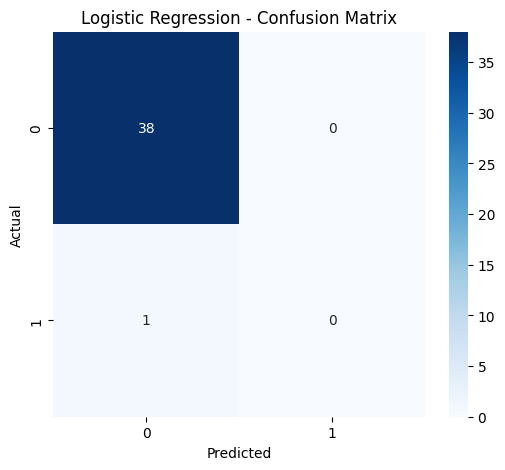


MODEL : Decision Tree

Accuracy Score : 0.9744
Precision Score : 0.5000
Recall Score : 1.0000
F1 Score : 0.6667

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.50      1.00      0.67         1

    accuracy                           0.97        39
   macro avg       0.75      0.99      0.83        39
weighted avg       0.99      0.97      0.98        39


Confusion Matrix:

[[37  1]
 [ 0  1]]


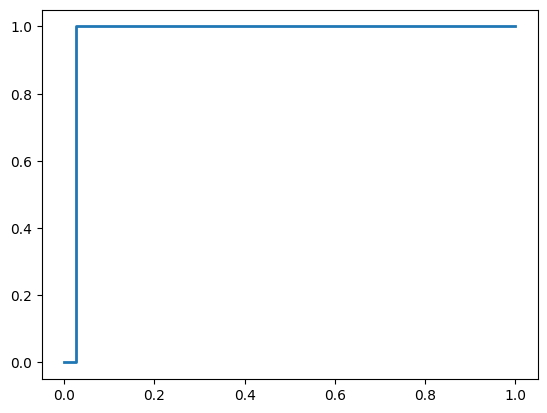

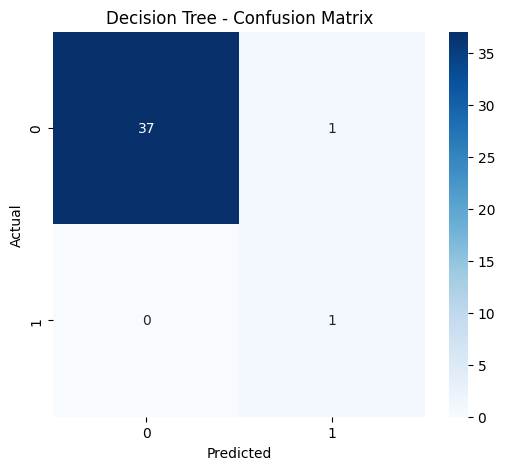


MODEL : Random Forest

Accuracy Score : 0.9744
Precision Score : 0.0000
Recall Score : 0.0000
F1 Score : 0.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


Confusion Matrix:

[[38  0]
 [ 1  0]]


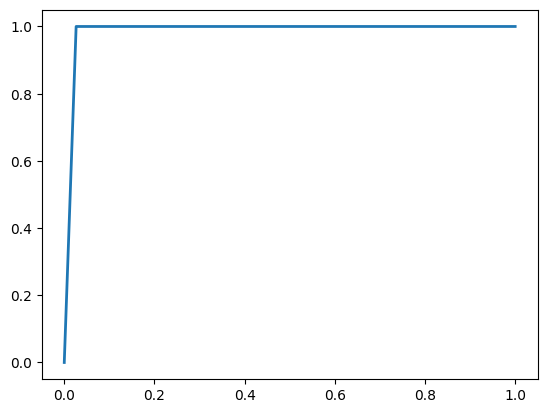

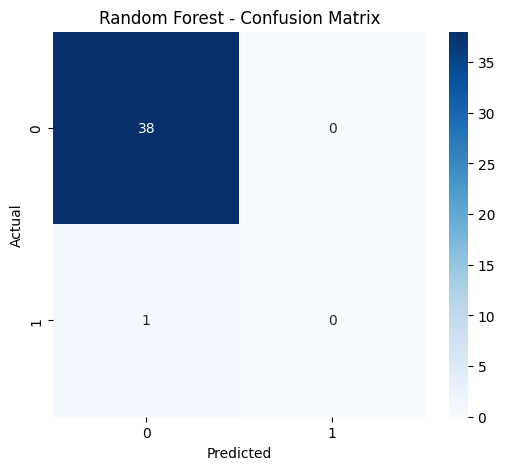


MODEL : KNN

Accuracy Score : 0.9744
Precision Score : 0.0000
Recall Score : 0.0000
F1 Score : 0.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


Confusion Matrix:

[[38  0]
 [ 1  0]]


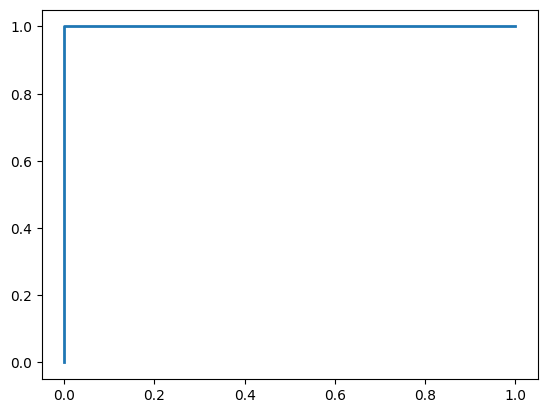

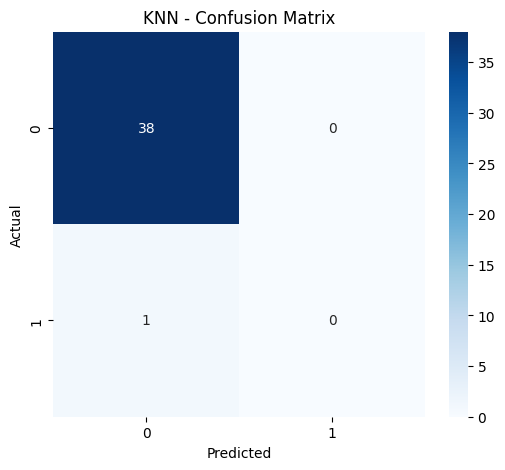


MODEL : SVM

Accuracy Score : 0.9744
Precision Score : 0.0000
Recall Score : 0.0000
F1 Score : 0.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


Confusion Matrix:

[[38  0]
 [ 1  0]]


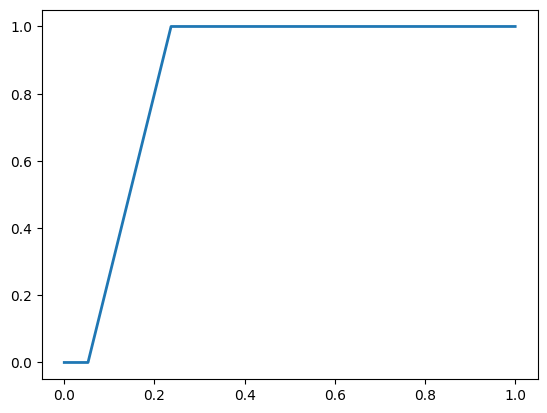

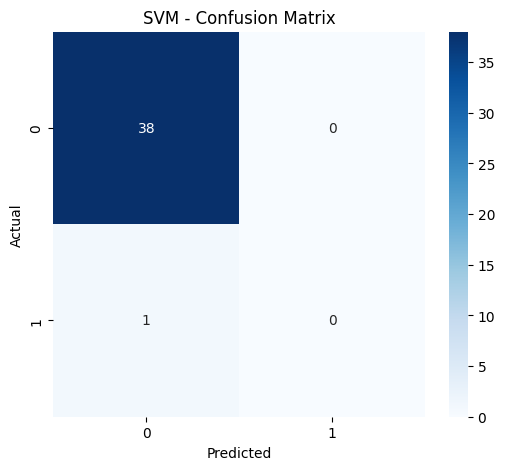


MODEL : Naive Bayes

Accuracy Score : 0.9744
Precision Score : 0.0000
Recall Score : 0.0000
F1 Score : 0.0000

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


Confusion Matrix:

[[38  0]
 [ 1  0]]


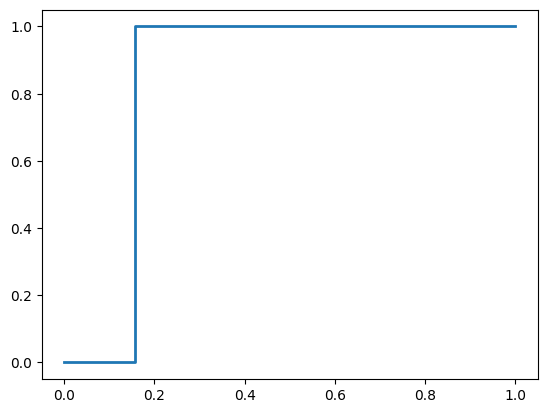

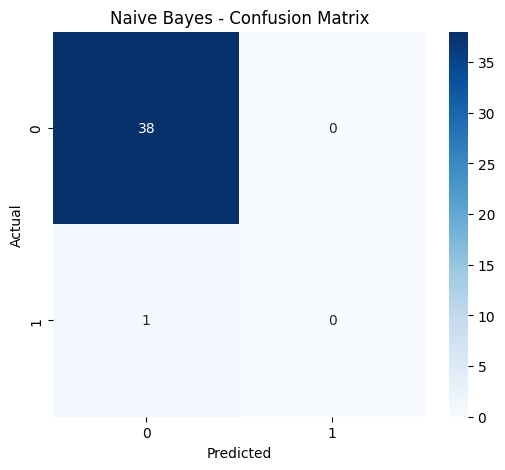

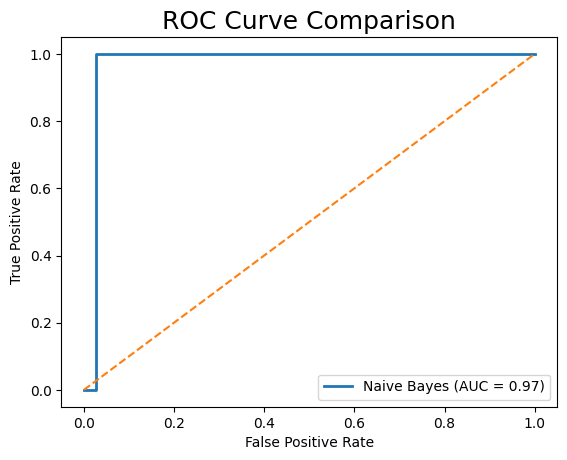


MODEL ACCURACY COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.974359
1        Decision Tree  0.974359
2        Random Forest  0.974359
3                  KNN  0.974359
4                  SVM  0.974359
5          Naive Bayes  0.974359


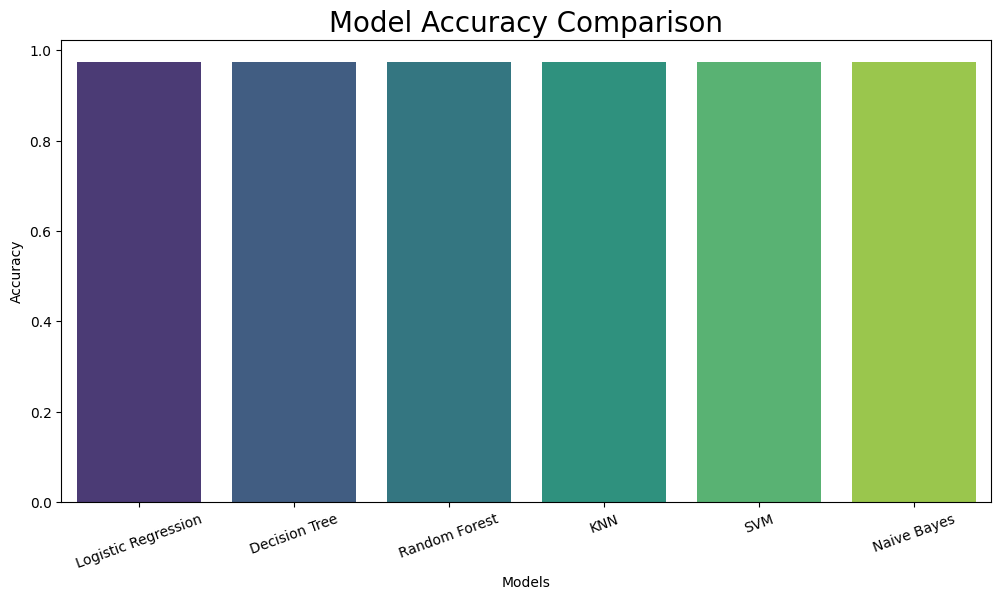


BEST MODEL
Best Model : Logistic Regression
Accuracy   : 0.9744

TOP FEATURE IMPORTANCE
                            Feature  Importance
20                         finalist    0.181117
4              goals_scored_last_4y    0.087712
21                    semi_finalist    0.079342
13                    squad_avg_age    0.071188
10     squad_total_market_value_eur    0.055748
11         fifa_rank_pre_tournament    0.052997
14  world_cup_participations_before    0.045581
12       fifa_points_pre_tournament    0.044556
17             quarterfinals_before    0.043434
6                      wins_last_4y    0.038923
5            goals_received_last_4y    0.036750
15             groups_passed_before    0.035478
18                semifinals_before    0.034930
8                     draws_last_4y    0.031036
1                              team    0.028360


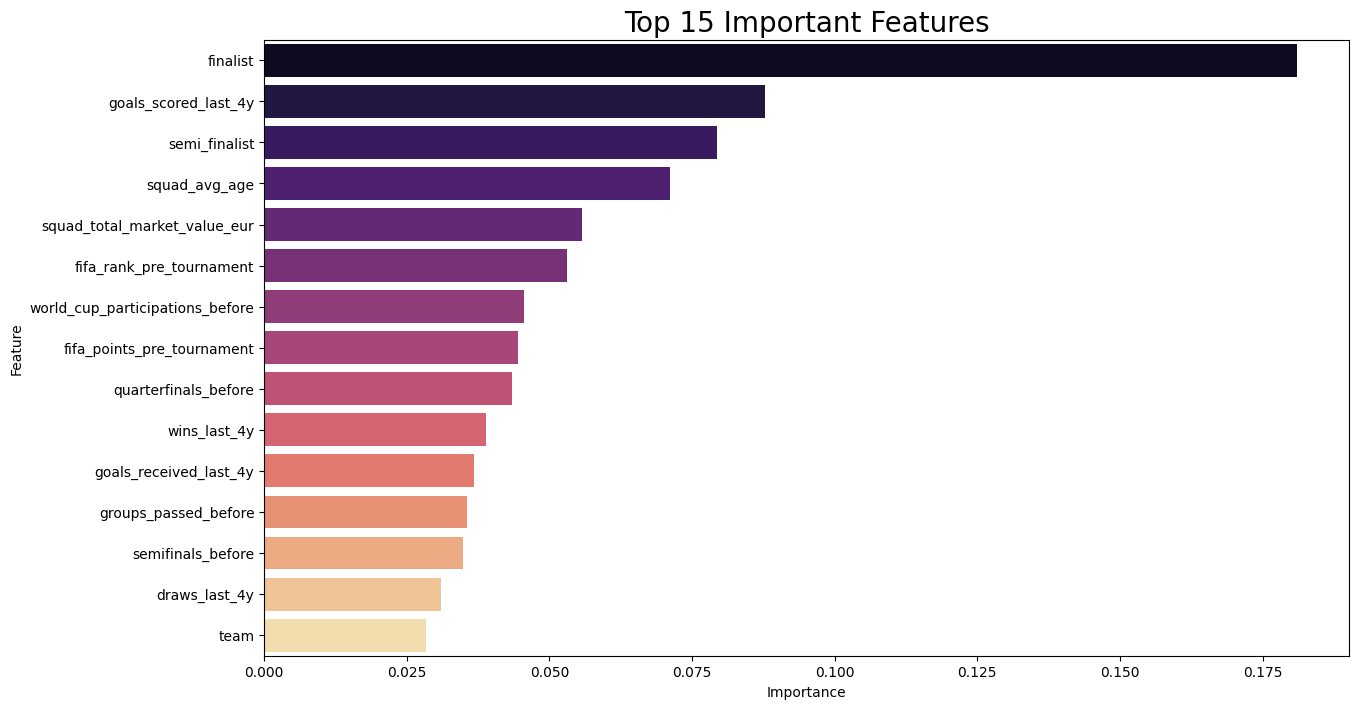


Processed Dataset Saved Successfully

MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [30]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)



num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numerical missing values
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values Handled Successfully")

# ============================================================
# STEP 6 : TARGET COLUMN
# ============================================================

target = 'winner'

print("\n==================================================")
print("TARGET COLUMN")
print("==================================================")

print("Target :", target)

print("\nTarget Value Counts:\n")
print(df[target].value_counts())

# ============================================================
# STEP 7 : FEATURE & TARGET SEPARATION
# ============================================================

X = df.drop(target, axis=1)

y = df[target]

print("\nFeature Shape :", X.shape)
print("Target Shape  :", y.shape)

# ============================================================
# STEP 8 : TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n==================================================")
print("TRAIN TEST SPLIT")
print("==================================================")

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

# ============================================================
# STEP 9 : SAFE LABEL ENCODING
# ============================================================

categorical_columns = X_train.select_dtypes(include='object').columns

# Safe encoder
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Fit only on training data
X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns]
)

# Transform test data
X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

# Encode target
target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

print("\nEncoding Completed Successfully")

# ============================================================
# STEP 10 : CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(18,12))

sns.heatmap(
    X_train.corr(),
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# ============================================================
# STEP 11 : MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "Naive Bayes": GaussianNB()
}

# ============================================================
# STEP 12 : MODEL TRAINING & EVALUATION
# ============================================================

accuracy_results = {}

# ROC Curve Figure
plt.figure(figsize=(12,8))

for name, model in models.items():

    print("\n==================================================")
    print(f"MODEL : {name}")
    print("==================================================")

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    model.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = model.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[name] = accuracy

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # PRECISION
    # ========================================================

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print(f"Precision Score : {precision:.4f}")

    # ========================================================
    # RECALL
    # ========================================================

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print(f"Recall Score : {recall:.4f}")

    # ========================================================
    # F1 SCORE
    # ========================================================

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print(f"F1 Score : {f1:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:\n")
    print(cm)

    # ========================================================
    # CONFUSION MATRIX PLOT
    # ========================================================

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} - Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)[:,1]

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f'{name} (AUC = {roc_auc:.2f})'
        )

# ============================================================
# STEP 13 : FINAL ROC CURVE
# ============================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison", fontsize=18)

plt.legend()

plt.show()

# ============================================================
# STEP 14 : MODEL ACCURACY COMPARISON
# ============================================================

accuracy_df = pd.DataFrame({

    'Model': accuracy_results.keys(),
    'Accuracy': accuracy_results.values()

})

accuracy_df = accuracy_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\n==================================================")
print("MODEL ACCURACY COMPARISON")
print("==================================================")

print(accuracy_df)

# ============================================================
# STEP 15 : ACCURACY BARPLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=20)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

# ============================================================
# STEP 16 : BEST MODEL
# ============================================================

best_model = accuracy_df.iloc[0]

print("\n==================================================")
print("BEST MODEL")
print("==================================================")

print("Best Model :", best_model['Model'])
print("Accuracy   :", round(best_model['Accuracy'], 4))

# ============================================================
# STEP 17 : FEATURE IMPORTANCE
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({

    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n==================================================")
print("TOP FEATURE IMPORTANCE")
print("==================================================")

print(importance_df.head(15))

# ============================================================
# STEP 18 : FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15),
    palette='magma'
)

plt.title("Top 15 Important Features", fontsize=20)

plt.show()

# ============================================================
# STEP 19 : SAVE PROCESSED DATA
# ============================================================

processed_df = pd.concat([
    X_train.reset_index(drop=True),
    pd.DataFrame(y_train, columns=[target])
], axis=1)

processed_df.to_csv(
    "processed_fifa_dataset.csv",
    index=False
)

print("\nProcessed Dataset Saved Successfully")

# ============================================================
# STEP 20 : FINAL MESSAGE
# ============================================================

print("\n==================================================")
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("==================================================")

## Thank you...pls upvote!!!!!!!!!!